# **Acne Segmentation — Simple U-Net**

## **Imports**

In [4]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


## **Configuration**

In [8]:
ROOT = "/kaggle/input/datasets/karmagames/acne04-v2/"

MASKS_DIR = os.path.join(ROOT, "gt_masks/gt_masks")

# For a baseline experiment, which involves only augmentations
IMAGES_DIR = os.path.join(ROOT, "img_data/img_data")

# For a ROI experiment, which involves extraction of facial ROI region
# IMAGES_DIR = os.path.join(ROOT, "clean_roi/clean_roi")

# For a CLAHE & ITA experiment, which involves CLAHE transform, conditioned on ITA
# IMAGES_DIR = os.path.join(ROOT, "images_acne_preprocess/images_acne_preprocess")


IMAGE_SIZE = 512
BATCH_SIZE = 2
NUM_EPOCHS = 40
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42
THRESHOLD = 0.5
CHECKPOINT_PATH = "best_simple_unet_acne.pth"

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)


Device: cuda


## **Dataset**

In [9]:
class RandomGamma:
    def __init__(self, gamma_range=(0.8, 1.25), p=0.5):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            gamma = random.uniform(*self.gamma_range)
            return TF.adjust_gamma(img, gamma)
        return img


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.8), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(*self.radius_range)
            return TF.gaussian_blur(img, kernel_size=3, sigma=sigma)
        return img


class AcneSegDataset(Dataset):
    def __init__(self, image_paths, images_dir, masks_dir, image_size=512, train=True):
        self.image_paths = image_paths
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.train = train

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015,
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.image_paths)

    def _get_image_path(self, image_item):
        image_item = Path(image_item)
        return image_item if image_item.exists() else self.images_dir / image_item.name

    def _get_mask_path(self, image_path):
        image_path = Path(image_path)
        return self.masks_dir / f"{image_path.stem}.png"

    def __getitem__(self, idx):
        image_path = self._get_image_path(self.image_paths[idx])
        mask_path = self._get_mask_path(image_path)

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        image = TF.to_pil_image(image)
        mask = TF.to_pil_image(mask)

        if self.train:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            image = self.color_aug(image)

        image = TF.to_tensor(image)
        image = self.normalize(image)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask


## **Data Split**

In [10]:
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_image_paths = []
for filename in sorted(os.listdir(IMAGES_DIR)):
    if Path(filename).suffix.lower() not in valid_exts:
        continue

    image_path = os.path.join(IMAGES_DIR, filename)
    mask_path = os.path.join(MASKS_DIR, f"{Path(filename).stem}.png")

    if os.path.exists(mask_path):
        all_image_paths.append(image_path)

print(f"Found {len(all_image_paths)} image-mask pairs")

train_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


Found 1204 image-mask pairs
Train: 963
Validation: 120
Test: 121


## **Data Loaders**

In [11]:
train_dataset = AcneSegDataset(train_paths, IMAGES_DIR, MASKS_DIR, image_size=IMAGE_SIZE, train=True)
val_dataset = AcneSegDataset(val_paths, IMAGES_DIR, MASKS_DIR, image_size=IMAGE_SIZE, train=False)
test_dataset = AcneSegDataset(test_paths, IMAGES_DIR, MASKS_DIR, image_size=IMAGE_SIZE, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## **Sample Batch**

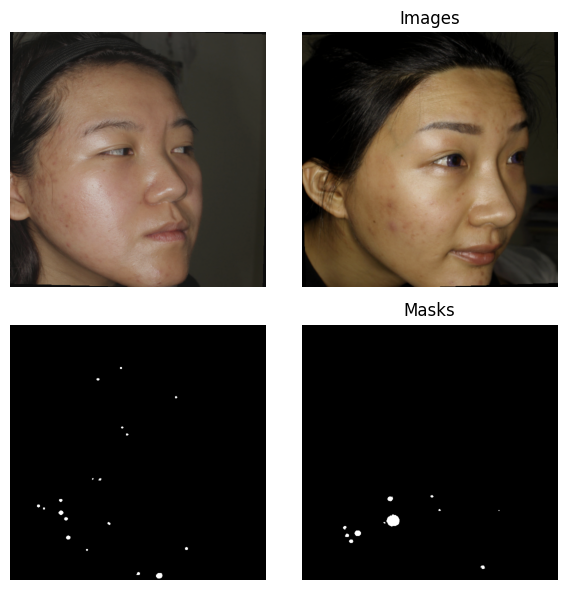

In [12]:
def denormalize_image(image):
    image = image.detach().cpu().clone()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image * std + mean
    return image.clamp(0, 1)


def show_batch_with_masks(loader):
    images, masks = next(iter(loader))
    batch_size = images.shape[0]

    fig, axes = plt.subplots(2, batch_size, figsize=(3 * batch_size, 6))

    if batch_size == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(batch_size):
        image = denormalize_image(images[i]).permute(1, 2, 0).numpy()
        mask = masks[i, 0].numpy()

        axes[0, i].imshow(image)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, batch_size // 2].set_title("Images")
    axes[1, batch_size // 2].set_title("Masks")
    plt.tight_layout()
    plt.show()


show_batch_with_masks(train_loader)


## **Model**

In [13]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, features[0])
        self.enc2 = DownBlock(features[0], features[1])
        self.enc3 = DownBlock(features[1], features[2])
        self.enc4 = DownBlock(features[2], features[3])

        self.bottleneck = DownBlock(features[3], features[3] * 2)

        self.dec4 = UpBlock(features[3] * 2, features[3], features[3])
        self.dec3 = UpBlock(features[3], features[2], features[2])
        self.dec2 = UpBlock(features[2], features[1], features[1])
        self.dec1 = UpBlock(features[1], features[0], features[0])

        self.out_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)

        x = self.bottleneck(s4)

        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return self.out_conv(x)


model = SimpleUNet(in_channels=3, out_channels=1, features=(64, 128, 256, 512)).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


## **Loss and Metrics**

In [14]:
bce_loss = nn.BCEWithLogitsLoss()


def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (probs.sum(dim=1) + targets.sum(dim=1) + smooth)

    return 1.0 - dice.mean()


def compute_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()


def pixel_metrics(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()

    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    return accuracy, precision, recall


## **Training Functions**

In [15]:
def train_one_epoch(model, loader, optimizer, device, epoch, epochs):
    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}", leave=False)

    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = compute_loss(logits, masks)
        loss.backward()
        optimizer.step()

        iou, dice = batch_iou_dice(logits.detach(), masks, threshold=THRESHOLD)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0
    eps = 1e-8

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = compute_loss(logits, masks)
        iou, dice = batch_iou_dice(logits, masks, threshold=threshold)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        total_tp += (preds * masks).sum().item()
        total_fp += (preds * (1 - masks)).sum().item()
        total_fn += ((1 - preds) * masks).sum().item()
        total_tn += ((1 - preds) * (1 - masks)).sum().item()

    n = len(loader)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)

    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }


## **Training**

In [ ]:
best_val_dice = -1.0
history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, DEVICE, epoch, NUM_EPOCHS)
    val_metrics = evaluate(model, val_loader, DEVICE, threshold=THRESHOLD)

    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"train_loss={train_metrics['loss']:.4f}, train_iou={train_metrics['iou']:.4f}, train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, val_iou={val_metrics['iou']:.4f}, val_dice={val_metrics['dice']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("Saved best model.")


Epoch 1/40:   0%|          | 0/482 [00:00<?, ?it/s]

## **Training Curves**

In [ ]:
def plot_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title("Training Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Validation Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_history(history)


## **Test Evaluation**

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

test_metrics = evaluate(model, test_loader, DEVICE, threshold=THRESHOLD)

print("==== TEST METRICS ====")
print(f"Loss:      {test_metrics['loss']:.4f}")
print(f"Dice:      {test_metrics['dice']:.4f}")
print(f"IoU:       {test_metrics['iou']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")


## **Predictions Visualization**

In [ ]:
def single_iou_dice(logit, target, threshold=0.5, eps=1e-8):
    if logit.ndim == 3:
        logit = logit.squeeze(0)
    if target.ndim == 3:
        target = target.squeeze(0)

    prob = torch.sigmoid(logit)
    pred = (prob > threshold).float()

    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred_flat.sum() + target_flat.sum() + eps)

    return iou.item(), dice.item(), prob.cpu().numpy()


def make_error_overlay(image, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = image.copy()
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


def show_predictions_overlay(images, masks, logits, n=4, threshold=0.5, alpha=0.45):
    n = min(n, images.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image = denormalize_image(images[i]).permute(1, 2, 0).numpy()
        gt = masks[i, 0].cpu().numpy()

        iou, dice, prob = single_iou_dice(logits[i], masks[i], threshold=threshold)
        pred = (prob > threshold).astype(np.float32)
        overlay = make_error_overlay(image, pred, gt, alpha=alpha)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction
Dice={dice:.3f}, IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay
Green=TP, Red=FP, Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


images_all = []
masks_all = []
logits_all = []

model.eval()
with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(test_loader):
        if batch_idx >= 2:
            break

        images_all.append(images.cpu())
        masks_all.append(masks.cpu())

        logits = model(images.to(DEVICE))
        logits_all.append(logits.cpu())

images_all = torch.cat(images_all, dim=0)
masks_all = torch.cat(masks_all, dim=0)
logits_all = torch.cat(logits_all, dim=0)

show_predictions_overlay(images_all, masks_all, logits_all, n=4, threshold=THRESHOLD)
